# Modelagem Comparativa de Séries Temporais com Variáveis Externas
## Grupo 1 — Base: *Bike Sales in Europe*
### Modelo de especialização: **XGBoost Regressor**



In [1]:
# 1. Setup e imports
import time
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterSampler
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

# o statsmodels redefine filtros de aviso ao ser importado: o filtro precisa vir DEPOIS dos imports
warnings.filterwarnings("ignore")

RNG = 42
np.random.seed(RNG)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

PALETTE = {
    "real": "#4B0082",          # roxo
    "SARIMAX": "#E91E8C",       # rosa
    "Holt-Winters": "#1E88E5",  # azul
    "Random Forest": "#00A896",
    "XGBoost": "#F2994A",
    "Ingênuo": "#9E9E9E",
    "Ingênuo sazonal": "#6D4C41",
}

GRUPO = 1
BASE_NOME = "Bike Sales in Europe"
MODELOS = ["SARIMAX", "Holt-Winters", "Random Forest", "XGBoost"]

## 5.1 Documentação e exploração da base

### Fonte, descrição, período e frequência
- **Fonte**: Kaggle — *Bike Sales in Europe* (sadiqshah).
- **Descrição**: registros transacionais de venda de bicicletas, acessórios e vestuário em lojas
  de seis países, com quantidade, custo, preço, lucro e receita por transação.
- **Variável-alvo**: `Revenue` (receita total, unidade monetária da base), agregada mensalmente.
- **Frequência**: dados transacionais sem frequência regular → regularização por soma mensal (`MS`).
- **Horizonte de previsão**: `h = 1` mês; origem da previsão = último dia do mês anterior.
- `Order_Quantity`, `Cost`, `Profit` e contagem de transações do **mesmo mês** não são usadas
  como preditoras: só são conhecidas junto com o próprio alvo.

In [2]:
# 2. Carregamento e congelamento da base bruta
CSV_PATH = "Sales.csv"
TARGET_COL = "Revenue"
ESCALA = 1e6  # os modelos trabalham com a receita em milhões (estabilidade numérica do SARIMAX)

df_raw = pd.read_csv(CSV_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]
df_raw["Date"] = pd.to_datetime(df_raw["Date"], errors="coerce")

df_raw.to_csv("bike_sales_base_congelada_bruta.csv", index=False)

print("Formato:", df_raw.shape)
print("Período coberto:", df_raw["Date"].min().date(), "a", df_raw["Date"].max().date())
print("\nTipos de dados:")
print(df_raw.dtypes)
df_raw.head()

Formato: (113036, 18)
Período coberto: 2011-01-01 a 2016-07-31

Tipos de dados:
Date                datetime64[ns]
Day                          int64
Month                       object
Year                         int64
Customer_Age                 int64
Age_Group                   object
Customer_Gender             object
Country                     object
State                       object
Product_Category            object
Sub_Category                object
Product                     object
Order_Quantity               int64
Unit_Cost                    int64
Unit_Price                   int64
Profit                       int64
Cost                         int64
Revenue                      int64
dtype: object


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


### Qualidade dos dados: ausentes, duplicidades, irregularidades e atípicos

Além das checagens usuais, dois testes estruturais são feitos porque afetam diretamente a
modelagem: (i) se o preço unitário de cada produto varia no tempo — o que define se a média de
preço pode ser tratada como "preço planejado" — e (ii) se há anos com registros espelhados.

In [3]:
# 3. Checagem de qualidade (nível transacional)
print("Valores ausentes por coluna:")
print(df_raw.isna().sum()[df_raw.isna().sum() > 0] if df_raw.isna().sum().sum() else "nenhum")

print(f"\nLinhas duplicadas exatas: {df_raw.duplicated().sum()}")
print(f"Datas inválidas: {df_raw['Date'].isna().sum()}")

# (i) preço e custo unitários por produto ao longo do tempo
n_precos = df_raw.groupby("Product")["Unit_Price"].nunique()
n_custos = df_raw.groupby("Product")["Unit_Cost"].nunique()
print(f"\nProdutos com mais de um Unit_Price no período: {(n_precos > 1).sum()} de {len(n_precos)}")
print(f"Produtos com mais de um Unit_Cost no período:  {(n_custos > 1).sum()} de {len(n_custos)}")
print("-> preço e custo são fixos por produto; a média mensal de Unit_Price só varia com o MIX vendido.")

# (ii) anos espelhados: mesma combinação dia/mês/cliente/estado/produto em dois anos diferentes
chave = ["Day", "Month", "Customer_Age", "Customer_Gender", "State", "Product"]
print("\nFração de combinações de um ano que reaparecem em outro ano:")
for ano_a, ano_b in [(2011, 2012), (2013, 2015), (2014, 2016)]:
    a = df_raw.loc[df_raw["Year"] == ano_a, chave].drop_duplicates()
    b = df_raw.loc[df_raw["Year"] == ano_b, chave].drop_duplicates()
    print(f"  {ano_a} -> {ano_b}: {len(a.merge(b, on=chave)) / len(a):.1%}")

# atípicos em nível de transação (IQR) — apenas descritivo
for col in ["Revenue", "Order_Quantity"]:
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_raw[col] < q1 - 1.5 * iqr) | (df_raw[col] > q3 + 1.5 * iqr)).sum()
    print(f"\n{col}: atípicos por IQR = {n_out} ({n_out / len(df_raw):.2%})")

Valores ausentes por coluna:
nenhum

Linhas duplicadas exatas: 1000
Datas inválidas: 0

Produtos com mais de um Unit_Price no período: 0 de 130
Produtos com mais de um Unit_Cost no período:  0 de 130
-> preço e custo são fixos por produto; a média mensal de Unit_Price só varia com o MIX vendido.

Fração de combinações de um ano que reaparecem em outro ano:
  2011 -> 2012: 100.0%
  2013 -> 2015: 100.0%
  2014 -> 2016: 100.0%

Revenue: atípicos por IQR = 14765 (13.06%)

Order_Quantity: atípicos por IQR = 0 (0.00%)


**Decisões de limpeza (nível transacional):**
- Duplicatas exatas são removidas antes da agregação.
- Atípicos transacionais em `Revenue` refletem a diferença de preço entre bicicletas e
  acessórios, não erros de registro; não são removidos.
- **Preço fixo por produto:** como nenhum produto muda de preço, `Unit_Price` médio mensal é
  um indicador de mix realizado, não uma decisão de preço planejada. Por isso entra apenas
  defasado (ver 5.3).
- **Anos espelhados:** 2012, 2015 e 2016 repetem as combinações de 2011, 2013 e 2014,
  respectivamente, com quantidades diferentes. Trata-se de um artefato de construção da base.
  Consequência metodológica: não se usa lag de 24 meses, pois exploraria o espelhamento e não
  um padrão de negócio.

In [4]:
# 4. Limpeza básica antes da agregação
df = (df_raw.drop_duplicates()
            .dropna(subset=["Date", TARGET_COL, "Order_Quantity", "Unit_Price", "Unit_Cost"])
            .copy())
print(f"Linhas após limpeza: {len(df)} (de {len(df_raw)} originais)")

Linhas após limpeza: 112036 (de 113036 originais)


## Agregação mensal, regularização e definição da série final

A agregação usa o calendário mensal completo (`MS`), inclusive meses sem registro. Dois tipos
de mês inválido são identificados:
- **sem registro**: nenhuma transação no mês;
- **incompleto**: há transações, mas nenhuma da categoria *Bikes* — presente em todos os demais
  meses desde jan/2011. Ocorre exatamente no último mês de cada bloco de extração (jul/2014 e
  jul/2016).

Tratamento:
- meses inválidos no **fim** da série são removidos (jul/2016);
- meses inválidos no **meio** da série (jul–dez/2014) são tratados como ausentes e imputados
  pelo valor do mesmo mês do ano anterior (`y[t-12]`). A imputação usa apenas informação
  anterior à lacuna, não usa nenhum dado do bloco de teste, e os meses imputados **nunca** são
  usados como origem de validação ou teste;
- variáveis externas realizadas desses meses são preenchidas com o último valor válido
  (`ffill`), também sem olhar para o futuro.

In [5]:
# 5. Agregação mensal e regularização
g = df.set_index("Date")
mensal = g.resample("MS").agg(
    Revenue=(TARGET_COL, "sum"),
    n_transacoes=(TARGET_COL, "count"),
    preco_medio=("Unit_Price", "mean"),
    custo_medio=("Unit_Cost", "mean"),
    idade_media=("Customer_Age", "mean"),
)

def mix_mensal(coluna, prefixo):
    # participação de cada categoria na quantidade vendida do mês (sem defasagem aqui)
    m = (g.groupby([pd.Grouper(freq="MS"), coluna])["Order_Quantity"].sum()
           .unstack(fill_value=0)
           .reindex(mensal.index, fill_value=0))
    return m.div(m.sum(axis=1).replace(0, np.nan), axis=0).add_prefix(prefixo)

mensal = (mensal.join(mix_mensal("Product_Category", "pct_cat_"))
                .join(mix_mensal("Country", "pct_pais_"))
                .join(mix_mensal("Customer_Gender", "pct_genero_")))

mensal["sem_registro"] = mensal["n_transacoes"] == 0
mensal["incompleto"] = (~mensal["sem_registro"]) & (mensal["pct_cat_Bikes"].fillna(0) == 0)
invalido = mensal["sem_registro"] | mensal["incompleto"]

print("Meses inválidos identificados:")
display(mensal.loc[invalido, ["Revenue", "n_transacoes", "pct_cat_Bikes", "sem_registro", "incompleto"]])

# remove meses inválidos no fim da série
while invalido.iloc[-1]:
    print(f"Removido do fim da série (mês incompleto): {mensal.index[-1].date()}")
    mensal, invalido = mensal.iloc[:-1], invalido.iloc[:-1]

mensal = mensal.copy()
mensal["imputado"] = invalido.values

# alvo: meses inválidos -> ausentes -> imputação sazonal ingênua (só passado)
y = mensal["Revenue"].astype(float).where(~mensal["imputado"])
for t in y.index[y.isna()]:
    y.loc[t] = y.loc[t - pd.DateOffset(months=12)]
mensal["y"] = y

# variáveis externas realizadas: meses inválidos -> último valor válido
EXT_REALIZADAS = (["preco_medio", "custo_medio", "idade_media", "n_transacoes"]
                  + [c for c in mensal.columns if c.startswith("pct_")])
mensal.loc[mensal["imputado"], EXT_REALIZADAS] = np.nan
mensal[EXT_REALIZADAS] = mensal[EXT_REALIZADAS].ffill()

mensal.to_csv("bike_sales_serie_mensal_congelada.csv")
print(f"\nSérie final: {len(mensal)} meses | {mensal.index.min().date()} a {mensal.index.max().date()} "
      f"| frequência = {pd.infer_freq(mensal.index)} | imputados = {mensal['imputado'].sum()}")

# atípicos na série mensal (meses observados)
obs = mensal.loc[~mensal["imputado"], "y"]
q1, q3 = obs.quantile([0.25, 0.75]); iqr = q3 - q1
print("Meses atípicos por IQR na série mensal:",
      list(obs[(obs < q1 - 1.5 * iqr) | (obs > q3 + 1.5 * iqr)].index.strftime("%Y-%m")) or "nenhum")

Meses inválidos identificados:


,Revenue,n_transacoes,pct_cat_Bikes,sem_registro,incompleto
Date,,,,,
2014-07-01,515765,2050,0.0,False,True
2014-08-01,0,0,NaN,True,False
2014-09-01,0,0,NaN,True,False
2014-10-01,0,0,NaN,True,False
2014-11-01,0,0,NaN,True,False
2014-12-01,0,0,NaN,True,False
2016-07-01,498424,2047,0.0,False,True


Removido do fim da série (mês incompleto): 2016-07-01

Série final: 66 meses | 2011-01-01 a 2016-06-01 | frequência = MS | imputados = 6
Meses atípicos por IQR na série mensal: nenhum


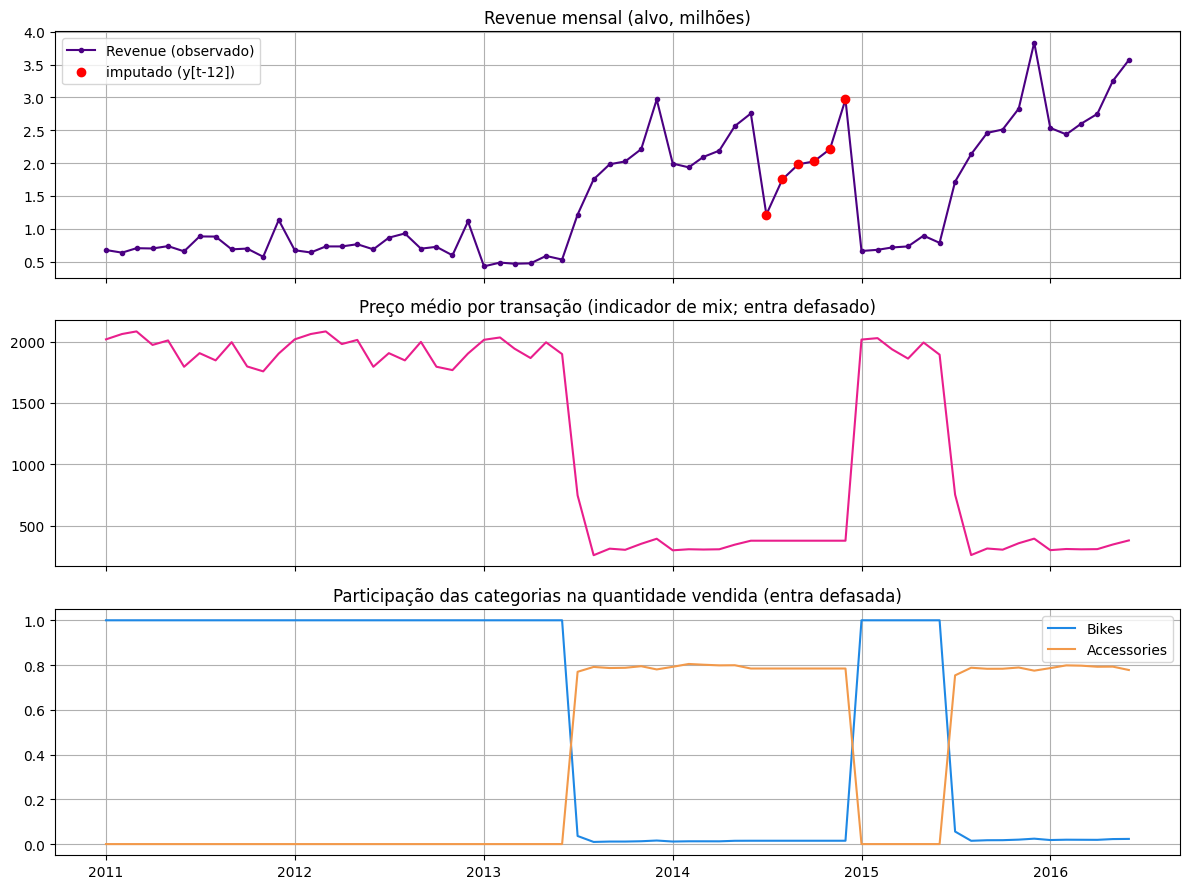

In [6]:
# 6. Visualização exploratória da série-alvo e das principais variáveis externas
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(mensal.index, mensal["y"] / ESCALA, color=PALETTE["real"], marker="o", ms=3, label="Revenue (observado)")
imp = mensal[mensal["imputado"]]
axes[0].scatter(imp.index, imp["y"] / ESCALA, color="red", zorder=3, label="imputado (y[t-12])")
axes[0].set_title("Revenue mensal (alvo, milhões)"); axes[0].legend()
axes[1].plot(mensal.index, mensal["preco_medio"], color=PALETTE["SARIMAX"])
axes[1].set_title("Preço médio por transação (indicador de mix; entra defasado)")
axes[2].plot(mensal.index, mensal["pct_cat_Bikes"], color=PALETTE["Holt-Winters"], label="Bikes")
axes[2].plot(mensal.index, mensal["pct_cat_Accessories"], color=PALETTE["XGBoost"], label="Accessories")
axes[2].set_title("Participação das categorias na quantidade vendida (entra defasada)"); axes[2].legend()
plt.tight_layout(); plt.show()

### Dicionário de variáveis externas

| Variável | Descrição | Unidade | Disponibilidade na origem | Uso |
|---|---|---|---|---|
| `mes_sin`, `mes_cos` | Encoding cíclico do mês | — | Conhecida com antecedência | Contemporânea |
| `preco_medio` | Média de `Unit_Price` nas transações do mês | moeda/unidade | Realizada (depende do mix) | Defasada 1 mês |
| `custo_medio` | Média de `Unit_Cost` nas transações do mês | moeda/unidade | Realizada (depende do mix) | Defasada 1 mês |
| `n_transacoes` | Número de transações no mês | contagem | Realizada | Defasada 1 mês |
| `idade_media` | Idade média dos clientes no mês | anos | Realizada | Defasada 1 mês |
| `pct_cat_*` | Participação de Bikes/Accessories/Clothing na quantidade | proporção | Realizada | Defasada 1 mês |
| `pct_pais_*` | Participação de cada país na quantidade | proporção | Realizada | Defasada 1 mês |
| `pct_genero_*` | Participação por gênero do cliente | proporção | Realizada | Defasada 1 mês |

Não há na base nenhuma variável de preço planejado com variação temporal: a lista de preços de
cada produto é constante no período. Uma previsão de preço/promoção conhecida antecipadamente
teria que vir de fonte externa.

## 5.2 Decomposição STL e características temporais

A STL e a força da sazonalidade são calculadas **apenas no período anterior ao teste**
(treino + validação), para que a escolha de `m` não use informação do bloco de teste.
Força conforme o método de aula: `F = max(0, 1 − Var(R) / Var(componente + R))`.

O período sazonal candidato não é fixado a priori: calcula-se F<sub>s</sub> para períodos
plausíveis em dados mensais (3, 4, 6 e 12) e os dois maiores valores definem os `m` testados
na busca do SARIMAX e do Holt-Winters.

,ciclos_completos,F_sazonal,F_tendencia
periodo,,,
3,18,0.000,0.814
4,13,0.040,0.781
6,9,0.395,0.782
12,4,0.330,0.509


Períodos sazonais candidatos para SARIMAX/Holt-Winters (2 maiores F_s): [6, 12]


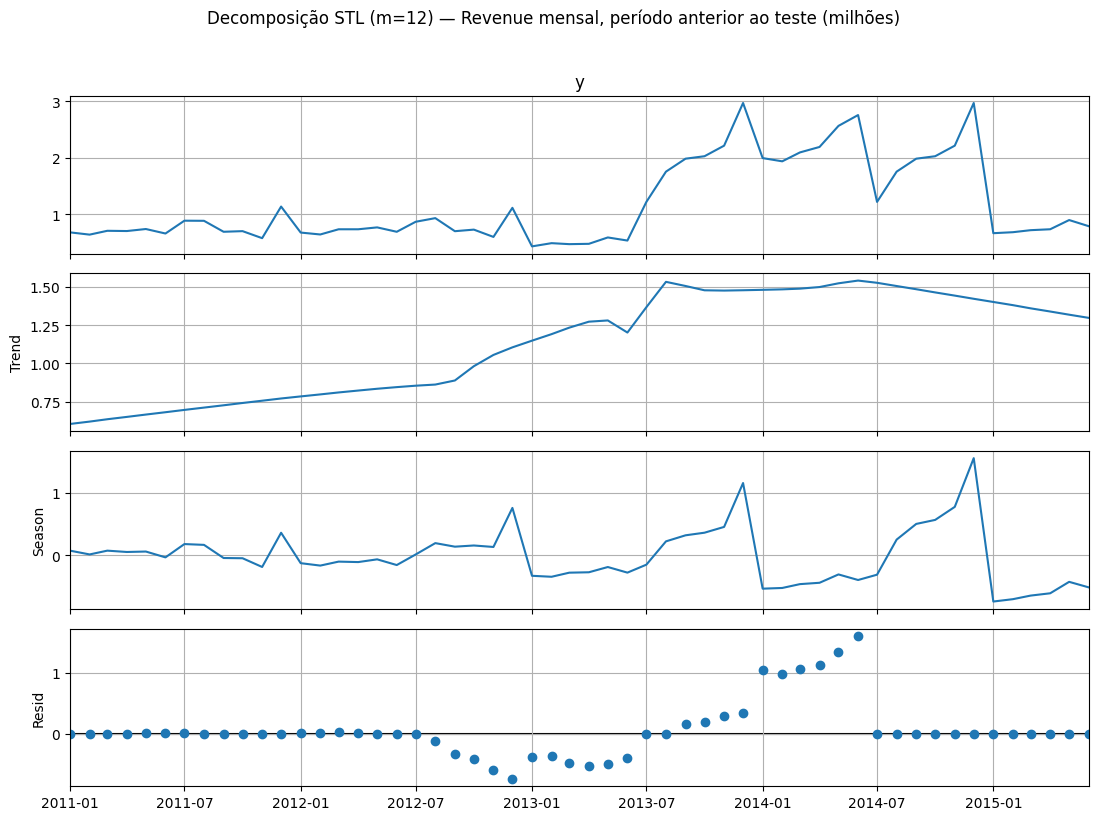

F_sazonal (m=12) = 0.330 | F_tendencia (m=12) = 0.509


In [7]:
# 7. STL e força da sazonalidade (somente período anterior ao teste)
N_TEST = 12
N_VAL = 12
inicio_teste = len(mensal) - N_TEST
serie_pre_teste = mensal["y"].iloc[:inicio_teste] / ESCALA

def forca_componente(componente, residuo):
    var_total = np.var(componente + residuo)
    return max(0.0, 1 - np.var(residuo) / var_total) if var_total > 0 else 0.0

linhas = []
for periodo in [3, 4, 6, 12]:
    r = STL(serie_pre_teste, period=periodo, robust=True).fit()
    linhas.append({"periodo": periodo,
                   "ciclos_completos": len(serie_pre_teste) // periodo,
                   "F_sazonal": forca_componente(r.seasonal, r.resid),
                   "F_tendencia": forca_componente(r.trend, r.resid)})
tabela_forca = pd.DataFrame(linhas).set_index("periodo")
display(tabela_forca.round(3))

M_CANDIDATOS = sorted(tabela_forca["F_sazonal"].nlargest(2).index.tolist())
print(f"Períodos sazonais candidatos para SARIMAX/Holt-Winters (2 maiores F_s): {M_CANDIDATOS}")

PERIODO_STL = 12  # período de calendário anual, usado na figura e na interpretação
res_stl = STL(serie_pre_teste, period=PERIODO_STL, robust=True).fit()
fig = res_stl.plot(); fig.set_size_inches(11, 8)
plt.suptitle(f"Decomposição STL (m={PERIODO_STL}) — Revenue mensal, período anterior ao teste (milhões)", y=1.02)
plt.tight_layout(); plt.show()
print(f"F_sazonal (m=12) = {forca_componente(res_stl.seasonal, res_stl.resid):.3f} | "
      f"F_tendencia (m=12) = {forca_componente(res_stl.trend, res_stl.resid):.3f}")

**Interpretação:**
- **Tendência:** patamar estável em 2011–2012 (somente Bikes); salto a partir de jul/2013, com a
  entrada de Accessories e Clothing; queda abrupta em jan/2015, quando a série volta a um
  patamar semelhante ao de 2013 (efeito do espelhamento de anos). A força de tendência alta
  reflete essas mudanças de nível mais do que um crescimento contínuo.
- **Sazonalidade:** F<sub>s</sub> moderado; picos recorrentes em dezembro. Parte do componente
  sazonal com m = 6 e m = 12 captura o salto de julho, que é uma mudança estrutural e não um
  padrão de calendário — limitação a declarar no relatório.
- **Resíduo:** concentrado nos meses de quebra (jul/2013, jan/2015) e na lacuna imputada.

In [8]:
# 7.1 Estacionariedade (apoio à escolha de d e D; o grid testa ambos)
def testes_estacionariedade(serie, nome):
    s = pd.Series(serie).dropna()
    adf_p = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]
    return {"série": nome, "n": len(s), "ADF p-valor": adf_p, "KPSS p-valor": kpss_p}

y_pre_val = serie_pre_teste.iloc[:-N_VAL]
display(pd.DataFrame([
    testes_estacionariedade(y_pre_val, "nível"),
    testes_estacionariedade(y_pre_val.diff(), "Δ1"),
    testes_estacionariedade(y_pre_val.diff(12), "Δ12"),
    testes_estacionariedade(y_pre_val.diff().diff(12), "Δ1Δ12"),
]).round(3))
print("ADF: H0 = raiz unitária (p < 0,05 sugere estacionária) | KPSS: H0 = estacionária (p < 0,05 sugere não estacionária)")

,série,n,ADF p-valor,KPSS p-valor
0,nível,42,1.000,0.021
1,Δ1,41,0.000,0.100
2,Δ12,30,0.968,0.017
3,Δ1Δ12,29,0.019,0.100


ADF: H0 = raiz unitária (p < 0,05 sugere estacionária) | KPSS: H0 = estacionária (p < 0,05 sugere não estacionária)


## 5.3 Feature Engineering

Features coerentes com `h = 1` mês: tudo o que entra na linha do mês *t* é conhecido no fim do
mês *t−1*.

- **Holt-Winters:** referência univariada; usa apenas a série do alvo.
- **SARIMAX:** o alvo (endógena) é sempre `Revenue`. As exógenas são escolhidas testando
  **todas as combinações de 3 variáveis** de um pool com todas as externas defasadas em 1 mês
  mais o calendário (seno + cosseno contam como um único item), além de três conjuntos-base
  (calendário; mix defasado; calendário + mix defasado). Não recebe lags do alvo como exógenas,
  pois os termos AR/MA já modelam essa dependência.
- **Random Forest e XGBoost:** o **mesmo** conjunto `FEATURE_COLS` — lags do alvo (1, 2, 3, 6,
  12), médias e desvios móveis (3, 6, 12) calculados com `shift(1)`, calendário cíclico e todas
  as externas realizadas defasadas em 1 mês.
- **Ausentes gerados por lags/janelas:** as primeiras linhas sem histórico suficiente (warm-up de
  12 meses) não entram como linhas de treino das árvores.

In [9]:
# 8. Feature engineering
base = mensal.copy()

for c in EXT_REALIZADAS:
    base[f"{c}_lag1"] = base[c].shift(1)

base["mes_sin"] = np.sin(2 * np.pi * base.index.month / 12)
base["mes_cos"] = np.cos(2 * np.pi * base.index.month / 12)

for l in (1, 2, 3, 6, 12):
    base[f"lag_{l}"] = base["y"].shift(l)
for w in (3, 6, 12):
    base[f"roll_mean_{w}"] = base["y"].shift(1).rolling(w).mean()
    base[f"roll_std_{w}"] = base["y"].shift(1).rolling(w).std()

FEATURES_ALVO = [c for c in base.columns if c.startswith(("lag_", "roll_"))]
FEATURES_CALENDARIO = ["mes_sin", "mes_cos"]
FEATURES_EXTERNAS = [f"{c}_lag1" for c in EXT_REALIZADAS]
FEATURE_COLS = FEATURES_ALVO + FEATURES_CALENDARIO + FEATURES_EXTERNAS

# conjuntos de exógenas do SARIMAX (o alvo é sempre o Revenue):
# 3 conjuntos-base + TODAS as combinações de TAMANHO_COMBINACAO itens de um pool com todas as
# externas defasadas e o calendário (seno+cosseno entra sempre como um único bloco)
EXOG_BASE = {
    "calendario": ["mes_sin", "mes_cos"],
    "mix_lag1": ["preco_medio_lag1", "pct_cat_Bikes_lag1"],
    "calendario+mix_lag1": ["mes_sin", "mes_cos", "preco_medio_lag1", "pct_cat_Bikes_lag1"],
}
TAMANHO_COMBINACAO = 3
# pct_genero_F = 1 - pct_genero_M: juntas são perfeitamente colineares, então só uma entra no pool
EXOG_POOL = {"calendario": ["mes_sin", "mes_cos"]}
EXOG_POOL.update({c: [c] for c in FEATURES_EXTERNAS if c != "pct_genero_F_lag1"})
# as participações de categoria somam 1: a combinação com todas elas juntas é descartada
PARTICAO_CAT = {c for c in EXOG_POOL if c.startswith("pct_cat_")}

EXOG_SETS = dict(EXOG_BASE)
for combo in itertools.combinations(EXOG_POOL, TAMANHO_COMBINACAO):
    if PARTICAO_CAT <= set(combo):
        continue
    EXOG_SETS.setdefault("+".join(combo), [col for nome in combo for col in EXOG_POOL[nome]])
EXOG_COMBOS = [k for k in EXOG_SETS if k not in EXOG_BASE]
print(f"Pool de exógenas: {len(EXOG_POOL)} itens | combinações de {TAMANHO_COMBINACAO}: {len(EXOG_COMBOS)} "
      f"| + {len(EXOG_BASE)} conjuntos-base")

# a 1ª linha não tem as externas _lag1 (NaN quebra o SARIMAX): todo SARIMAX, com ou sem
# exógenas, é ajustado a partir de INICIO_SARIMAX, para que as configurações sejam comparáveis
COLS_EXOG = sorted({c for cols in EXOG_SETS.values() for c in cols})
INICIO_SARIMAX = int(np.argmax(base[COLS_EXOG].notna().all(axis=1).values))
print(f"SARIMAX ajustado a partir de {base.index[INICIO_SARIMAX].date()} (linha {INICIO_SARIMAX})")

INICIO_FEATURES = int(np.argmax(base[FEATURE_COLS].notna().all(axis=1).values))
print(f"Features para árvores: {len(FEATURE_COLS)} "
      f"({len(FEATURES_ALVO)} do alvo, {len(FEATURES_CALENDARIO)} de calendário, {len(FEATURES_EXTERNAS)} externas)")
print(f"Primeira linha com todas as features: {base.index[INICIO_FEATURES].date()} (warm-up de {INICIO_FEATURES} meses)")

Pool de exógenas: 15 itens | combinações de 3: 454 | + 3 conjuntos-base
SARIMAX ajustado a partir de 2011-02-01 (linha 1)
Features para árvores: 28 (11 do alvo, 2 de calendário, 15 externas)
Primeira linha com todas as features: 2012-01-01 (warm-up de 12 meses)


## 5.4 Validação walk-forward

- Janela expansiva: na origem *t*, o treino usa todos os meses anteriores a *t*; prevê-se o mês *t*
  (`h = 1`); em seguida *t* entra no histórico.
- **Teste:** os últimos 12 meses (jul/2015 a jun/2016).
- **Validação:** os 12 últimos meses **observados** antes do teste. Os meses imputados
  (jul–dez/2014) não servem de origem, então a validação cobre jan–jun/2014 e jan–jun/2015.
- Os quatro modelos usam as mesmas origens, o mesmo horizonte e o mesmo bloco de teste, e os
  hiperparâmetros escolhidos na validação ficam fixos no teste.
- Além dos quatro modelos, duas **referências sem parâmetros** passam pelas mesmas origens: a ingênua
  (`y[t-1]`) e a ingênua sazonal (`y[t-12]`, o mesmo mês do ano anterior). Um modelo só se justifica
  se superar ambas.

In [10]:
# 9. Blocos temporais e função genérica de walk-forward
n = len(base)
idx = base.index
Y = base["y"].values / ESCALA
OBSERVADO = ~base["imputado"].values

ORIGENS_TESTE = list(range(n - N_TEST, n))
ORIGENS_VAL = [t for t in range(n - N_TEST) if OBSERVADO[t]][-N_VAL:]
assert all(OBSERVADO[t] for t in ORIGENS_TESTE), "Há mês imputado no bloco de teste."
assert ORIGENS_VAL[0] > INICIO_FEATURES + 12, "Treino inicial curto demais."

print(f"Treino inicial: {idx[0].date()} a {idx[ORIGENS_VAL[0] - 1].date()} ({ORIGENS_VAL[0]} meses)")
print(f"Validação ({len(ORIGENS_VAL)} origens): {', '.join(idx[ORIGENS_VAL].strftime('%Y-%m'))}")
print(f"Teste ({len(ORIGENS_TESTE)} origens): {idx[ORIGENS_TESTE[0]].date()} a {idx[ORIGENS_TESTE[-1]].date()}")

def walk_forward(prever, origens):
    # prever(t) recebe o índice da origem e só pode usar dados de 0..t-1 (e exógenas conhecidas em t)
    return np.array([prever(t) for t in origens])

def mae_walk_forward(prever, origens):
    try:
        prev = walk_forward(prever, origens)
    except Exception:
        return np.inf
    return float(np.mean(np.abs(Y[origens] - prev))) if np.all(np.isfinite(prev)) else np.inf

def prever_ingenuo(t):
    return Y[t - 1]

M_SAZONAL = 12   # ciclo anual de uma série mensal

def prever_ingenuo_sazonal(t):
    return Y[t - M_SAZONAL]   # mesmo mês do ano anterior

print(f"\nReferência ingênua (y[t-1]) — MAE validação: {mae_walk_forward(prever_ingenuo, ORIGENS_VAL) * ESCALA:,.0f}")
print(f"Referência ingênua sazonal (y[t-{M_SAZONAL}]) — MAE validação: {mae_walk_forward(prever_ingenuo_sazonal, ORIGENS_VAL) * ESCALA:,.0f}")

Treino inicial: 2011-01-01 a 2013-12-01 (36 meses)
Validação (12 origens): 2014-01, 2014-02, 2014-03, 2014-04, 2014-05, 2014-06, 2015-01, 2015-02, 2015-03, 2015-04, 2015-05, 2015-06
Teste (12 origens): 2015-07-01 a 2016-06-01

Referência ingênua (y[t-1]) — MAE validação: 375,259
Referência ingênua sazonal (y[t-12]) — MAE validação: 1,635,225


## 5.5 Otimização de hiperparâmetros

Critério único para os quatro modelos: **MAE walk-forward nas origens de validação**. Nenhuma
decisão usa o bloco de teste.

### SARIMAX — busca em duas etapas
1. **Triagem por AIC/BIC** (ajuste único no treino inicial): grade completa
   `p, q ∈ {0,1,2}`, `d ∈ {0,1}`, `P, Q ∈ {0,1}`, `D ∈ {0,1}`, `m ∈ M_CANDIDATOS`, em nível e em
   log. Como AIC só é comparável entre modelos com a mesma diferenciação e a mesma
   transformação, seleciona-se as 2 melhores ordens **dentro** de cada grupo
   `(transformação, d, D, m)`.
2. **Decisão por MAE walk-forward**:
   - **2a:** cada ordem triada é testada sem exógenas (referência SARIMA) e com os três
     conjuntos-base;
   - **2b:** as `TOP_ORDENS` melhores ordens da 2a são testadas com **todas as combinações de 3
     exógenas** do pool. São milhares de ajustes (horas em série), então a etapa roda em paralelo
     em todos os núcleos e grava cada lote em `bike_sales_busca_exog_sarimax.csv`: se o kernel
     for interrompido, basta rodar a célula de novo que ela retoma de onde parou.

   O SARIMAX final é o de menor MAE entre as configurações **com** exógenas.

Previsões em log são revertidas com `exp`, o que estima a mediana condicional — o estimador
ótimo para MAE.

In [11]:
# 10.1 SARIMAX — etapa 1: triagem por AIC/BIC dentro de cada grupo (transformação, d, D, m)
def ajustar_sarimax(y_treino, order, seasonal_order, exog=None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(y_treino, exog=exog, order=order, seasonal_order=seasonal_order).fit(disp=False, maxiter=200)

t_ini = time.time()
y_treino_inicial = Y[INICIO_SARIMAX:ORIGENS_VAL[0]]
linhas = []
for transf in ["nivel", "log"]:
    y_aj = np.log(y_treino_inicial) if transf == "log" else y_treino_inicial
    for m in M_CANDIDATOS:
        for p, d, q, P, D, Q in itertools.product([0, 1, 2], [0, 1], [0, 1, 2], [0, 1], [0, 1], [0, 1]):
            registro = {"transf": transf, "order": (p, d, q), "seasonal_order": (P, D, Q, m),
                        "d": d, "D": D, "m": m, "aic": np.inf, "bic": np.inf, "convergiu": False}
            try:
                r = ajustar_sarimax(y_aj, (p, d, q), (P, D, Q, m))
                registro.update(aic=r.aic, bic=r.bic, convergiu=bool(r.mle_retvals.get("converged", True)))
            except Exception:
                pass
            linhas.append(registro)

triagem_sarimax = pd.DataFrame(linhas)
validos = triagem_sarimax[triagem_sarimax["convergiu"] & np.isfinite(triagem_sarimax["aic"])]
print(f"Ajustes na triagem: {len(triagem_sarimax)} | sem convergência ou com erro: {len(triagem_sarimax) - len(validos)} "
      f"| tempo: {time.time() - t_ini:.0f}s")

candidatos_sarimax = (validos.sort_values("aic")
                             .groupby(["transf", "d", "D", "m"]).head(2)
                             .sort_values(["transf", "d", "D", "m", "aic"])
                             .reset_index(drop=True))
display(candidatos_sarimax[["transf", "order", "seasonal_order", "aic", "bic"]].round(2))

Ajustes na triagem: 576 | sem convergência ou com erro: 3 | tempo: 119s


,transf,order,seasonal_order,aic,bic
0,log,"(1, 0, 2)","(1, 0, 1, 6)",6.15,15.49
1,log,"(2, 0, 2)","(1, 0, 1, 6)",7.91,18.80
2,log,"(2, 0, 2)","(1, 0, 0, 12)",0.49,9.82
3,log,"(2, 0, 2)","(1, 0, 1, 12)",2.35,13.24
4,log,"(2, 0, 2)","(1, 1, 0, 6)",7.54,15.74
5,log,"(2, 0, 2)","(1, 1, 1, 6)",9.02,18.59
6,log,"(2, 0, 2)","(0, 1, 0, 12)",-6.56,-0.88
7,log,"(2, 0, 2)","(1, 1, 0, 12)",-5.04,1.77
8,log,"(2, 1, 0)","(1, 0, 1, 6)",4.37,12.00
9,log,"(0, 1, 2)","(1, 0, 1, 6)",4.59,12.22


In [12]:
# 10.2 SARIMAX — etapa 2: MAE walk-forward na validação (ordens triadas × conjuntos de exógenas)
import os
import ast
from joblib import Parallel, delayed

def prever_sarimax(t, cfg, X=None):
    # X: matriz (n × k) das exógenas do conjunto; se omitida, é montada a partir de EXOG_SETS
    y_tr = Y[INICIO_SARIMAX:t]
    if cfg["transf"] == "log":
        y_tr = np.log(y_tr)
    X_tr = X_prev = None
    if cfg["exog"] is not None:
        if X is None:
            X = base[EXOG_SETS[cfg["exog"]]].values.astype(float)
        padronizador = StandardScaler().fit(X[INICIO_SARIMAX:t])   # ajuste só no treino da origem
        X_tr = padronizador.transform(X[INICIO_SARIMAX:t])
        X_prev = padronizador.transform(X[t:t + 1])
    r = ajustar_sarimax(y_tr, cfg["order"], cfg["seasonal_order"], X_tr)
    p = float(np.asarray(r.forecast(1, exog=X_prev))[0])
    return np.exp(p) if cfg["transf"] == "log" else p

def avaliar_sarimax(cfg, X=None):
    return mae_walk_forward(lambda t: prever_sarimax(t, cfg, X), ORIGENS_VAL)

# etapa 2a: todas as ordens triadas × (sem exógenas + conjuntos-base)
N_JOBS = -1               # -1 = todos os núcleos
t_ini = time.time()
cfgs_a = [{"transf": c["transf"], "order": c["order"], "seasonal_order": c["seasonal_order"],
           "exog": exog, "aic_triagem": c["aic"]}
          for _, c in candidatos_sarimax.iterrows() for exog in [None] + list(EXOG_BASE)]
maes_a = Parallel(n_jobs=N_JOBS)(delayed(avaliar_sarimax)(cfg) for cfg in cfgs_a)
busca_a = pd.DataFrame([{**cfg, "mae_val": m} for cfg, m in zip(cfgs_a, maes_a)]).sort_values("mae_val")
print(f"Etapa 2a: {len(busca_a)} configurações | descartadas por falha: {np.isinf(busca_a['mae_val']).sum()} "
      f"| tempo: {time.time() - t_ini:.0f}s")

# etapa 2b: TOP_ORDENS melhores ordens × TODAS as combinações de 3 exógenas
TOP_ORDENS = 5            # aumentar amplia a busca (o tempo cresce linearmente)
TAMANHO_LOTE = 120        # configurações por lote gravado no checkpoint
CHECKPOINT = "bike_sales_busca_exog_sarimax.csv"
REINICIAR_BUSCA = False   # True apaga o checkpoint (obrigatório se mudar dados, origens ou pool)

chaves = ["transf", "order", "seasonal_order"]
top_ordens = busca_a.drop_duplicates(chaves).head(TOP_ORDENS)[chaves + ["aic_triagem"]]
pendentes = [{"transf": c["transf"], "order": c["order"], "seasonal_order": c["seasonal_order"],
              "exog": exog, "aic_triagem": c["aic_triagem"]}
             for _, c in top_ordens.iterrows() for exog in EXOG_COMBOS]
n_total = len(pendentes)

def chave_cfg(cfg):
    return (cfg["transf"], tuple(cfg["order"]), tuple(cfg["seasonal_order"]), cfg["exog"])

if REINICIAR_BUSCA and os.path.exists(CHECKPOINT):
    os.remove(CHECKPOINT)
feitos = pd.DataFrame()
if os.path.exists(CHECKPOINT):
    feitos = pd.read_csv(CHECKPOINT)
    for col in ["order", "seasonal_order"]:
        feitos[col] = feitos[col].apply(ast.literal_eval)
    ja_avaliado = {chave_cfg(r) for r in feitos.to_dict("records")}
    pendentes = [c for c in pendentes if chave_cfg(c) not in ja_avaliado]

print(f"Etapa 2b: {len(top_ordens)} ordens × {len(EXOG_COMBOS)} combinações = {n_total} configurações "
      f"({n_total * len(ORIGENS_VAL)} ajustes) | já no checkpoint: {n_total - len(pendentes)} "
      f"| pendentes: {len(pendentes)}")

t_ini = time.time()
with Parallel(n_jobs=N_JOBS) as paralelo:
    for i in range(0, len(pendentes), TAMANHO_LOTE):
        lote = pendentes[i:i + TAMANHO_LOTE]
        maes = paralelo(delayed(avaliar_sarimax)(cfg, base[EXOG_SETS[cfg["exog"]]].values.astype(float))
                        for cfg in lote)
        res_lote = pd.DataFrame([{**cfg, "mae_val": m} for cfg, m in zip(lote, maes)])
        res_lote.to_csv(CHECKPOINT, mode="a", header=not os.path.exists(CHECKPOINT), index=False)
        feitos = pd.concat([feitos, res_lote], ignore_index=True)
        concluidos, decorrido = i + len(lote), time.time() - t_ini
        print(f"  {concluidos}/{len(pendentes)} | {decorrido / 60:.1f} min | "
              f"restante ≈ {decorrido / concluidos * (len(pendentes) - concluidos) / 60:.1f} min | "
              f"melhor MAE até agora: {feitos['mae_val'].min() * ESCALA:,.0f}", flush=True)

busca_sarimax = (pd.concat([busca_a, feitos], ignore_index=True)
                   .assign(_k=lambda d: [chave_cfg(r) for r in d.to_dict("records")])
                   .drop_duplicates("_k").drop(columns="_k")
                   .sort_values("mae_val").reset_index(drop=True))
n_falhas = np.isinf(busca_sarimax["mae_val"]).sum()
print(f"\nConfigurações avaliadas: {len(busca_sarimax)} × {len(ORIGENS_VAL)} origens "
      f"= {len(busca_sarimax) * len(ORIGENS_VAL)} ajustes | descartadas por falha: {n_falhas} "
      f"| tempo desta execução (2b): {(time.time() - t_ini) / 60:.1f} min")

tab = busca_sarimax.copy(); tab["mae_val"] = tab["mae_val"] * ESCALA
print("\nTop 15 configurações:")
display(tab.head(15).round(1))

# frequência de cada exógena entre as 20 melhores combinações de 3
top_combos = busca_sarimax[busca_sarimax["exog"].isin(EXOG_COMBOS)].head(20)
freq = pd.Series([item for e in top_combos["exog"] for item in e.split("+")]).value_counts()
print("\nFrequência de cada exógena nas 20 melhores combinações de 3:")
display(freq.to_frame("aparições"))

colunas_cfg = ["transf", "order", "seasonal_order", "exog"]
MELHOR_SARIMAX = busca_sarimax[busca_sarimax["exog"].notna()].iloc[0][colunas_cfg].to_dict()
MELHOR_SARIMA_REF = busca_sarimax[busca_sarimax["exog"].isna()].iloc[0][colunas_cfg].to_dict()
mae_sarimax_val = busca_sarimax[busca_sarimax["exog"].notna()].iloc[0]["mae_val"] * ESCALA
mae_sarima_val = busca_sarimax[busca_sarimax["exog"].isna()].iloc[0]["mae_val"] * ESCALA
print(f"\nSARIMAX escolhido: {MELHOR_SARIMAX} | colunas: {EXOG_SETS[MELHOR_SARIMAX['exog']]} "
      f"| MAE val = {mae_sarimax_val:,.0f}")
print(f"Referência SARIMA (sem exógenas): {MELHOR_SARIMA_REF} | MAE val = {mae_sarima_val:,.0f}")


Etapa 2a: 128 configurações | descartadas por falha: 0 | tempo: 113s
Etapa 2b: 5 ordens × 454 combinações = 2270 configurações (27240 ajustes) | já no checkpoint: 0 | pendentes: 2270
  120/2270 | 1.4 min | restante ≈ 25.5 min | melhor MAE até agora: 223,661
  240/2270 | 2.9 min | restante ≈ 24.4 min | melhor MAE até agora: 223,661
  360/2270 | 4.1 min | restante ≈ 21.9 min | melhor MAE até agora: 218,118
  480/2270 | 5.4 min | restante ≈ 20.0 min | melhor MAE até agora: 205,392
  600/2270 | 6.7 min | restante ≈ 18.7 min | melhor MAE até agora: 186,059
  720/2270 | 8.1 min | restante ≈ 17.5 min | melhor MAE até agora: 175,159
  840/2270 | 9.5 min | restante ≈ 16.1 min | melhor MAE até agora: 175,159
  960/2270 | 10.2 min | restante ≈ 14.0 min | melhor MAE até agora: 175,159
  1080/2270 | 10.6 min | restante ≈ 11.7 min | melhor MAE até agora: 175,159
  1200/2270 | 11.0 min | restante ≈ 9.8 min | melhor MAE até agora: 175,159
  1320/2270 | 11.5 min | restante ≈ 8.2 min | melhor MAE até ag

,transf,order,seasonal_order,exog,aic_triagem,mae_val
0,log,"(0, 1, 2)","(1, 1, 0, 6)",idade_media_lag1+pct_cat_Accessories_lag1+pct_...,10.3,175158.9
1,log,"(0, 1, 2)","(1, 1, 0, 6)",idade_media_lag1+pct_cat_Bikes_lag1+pct_pais_G...,10.3,175454.1
2,log,"(0, 1, 2)","(1, 1, 0, 6)",pct_cat_Accessories_lag1+pct_pais_France_lag1+...,10.3,176364.0
3,log,"(0, 1, 2)","(1, 1, 0, 6)",pct_cat_Bikes_lag1+pct_pais_France_lag1+pct_pa...,10.3,176867.0
4,log,"(0, 1, 2)","(1, 1, 0, 6)",pct_cat_Accessories_lag1+pct_pais_Germany_lag1...,10.3,178144.4
5,log,"(0, 1, 2)","(1, 1, 0, 6)",pct_cat_Bikes_lag1+pct_pais_Germany_lag1+pct_p...,10.3,179037.4
6,log,"(0, 1, 2)","(1, 1, 0, 6)",idade_media_lag1+pct_cat_Clothing_lag1+pct_pai...,10.3,183615.8
7,log,"(0, 1, 2)","(1, 1, 0, 6)",calendario+pct_cat_Accessories_lag1+pct_pais_G...,10.3,186058.7
8,log,"(0, 1, 2)","(1, 1, 0, 6)",pct_cat_Bikes_lag1+pct_pais_Germany_lag1+pct_g...,10.3,187238.9
9,log,"(0, 1, 2)","(1, 1, 0, 6)",pct_cat_Clothing_lag1+pct_pais_France_lag1+pct...,10.3,187980.4



Frequência de cada exógena nas 20 melhores combinações de 3:


,aparições
pct_pais_Germany_lag1,20
pct_cat_Accessories_lag1,7
pct_cat_Bikes_lag1,6
pct_cat_Clothing_lag1,6
pct_pais_Canada_lag1,4
idade_media_lag1,3
pct_pais_France_lag1,3
pct_pais_United Kingdom_lag1,3
calendario,3
pct_genero_M_lag1,3



SARIMAX escolhido: {'transf': 'log', 'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 6), 'exog': 'idade_media_lag1+pct_cat_Accessories_lag1+pct_pais_Germany_lag1'} | colunas: ['idade_media_lag1', 'pct_cat_Accessories_lag1', 'pct_pais_Germany_lag1'] | MAE val = 175,159
Referência SARIMA (sem exógenas): {'transf': 'log', 'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 6), 'exog': None} | MAE val = 251,536


In [13]:
# 10.3 Holt-Winters — grade completa por MAE walk-forward na validação
def prever_hw(t, cfg):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        modelo = ExponentialSmoothing(
            Y[:t], trend=cfg["trend"], damped_trend=cfg["damped"], seasonal=cfg["seasonal"],
            seasonal_periods=cfg["m"] if cfg["seasonal"] else None,
            use_boxcox=cfg["boxcox"], initialization_method="estimated",
        ).fit()   # alpha, beta, gamma e phi estimados por máxima verossimilhança em cada origem
    return float(np.asarray(modelo.forecast(1))[0])

t_ini = time.time()
linhas = []
for trend, damped, seasonal, m, boxcox in itertools.product(
        [None, "add", "mul"], [False, True], [None, "add", "mul"], M_CANDIDATOS, [False, True]):
    if trend is None and damped:
        continue
    if seasonal is None and m != M_CANDIDATOS[0]:
        continue  # sem sazonalidade, m é irrelevante
    cfg = {"trend": trend, "damped": damped, "seasonal": seasonal,
           "m": m if seasonal else None, "boxcox": boxcox}
    linhas.append({**cfg, "mae_val": mae_walk_forward(lambda t, cfg=cfg: prever_hw(t, cfg), ORIGENS_VAL)})

busca_hw = pd.DataFrame(linhas).sort_values("mae_val").reset_index(drop=True)
print(f"Configurações: {len(busca_hw)} | descartadas por falha: {np.isinf(busca_hw['mae_val']).sum()} "
      f"| tempo: {time.time() - t_ini:.0f}s")
tab = busca_hw.copy(); tab["mae_val"] = tab["mae_val"] * ESCALA
display(tab.head(10).round(1))

MELHOR_HW = {k: (None if pd.isna(v) else v) for k, v in busca_hw.iloc[0].drop("mae_val").to_dict().items()}
MELHOR_HW["damped"] = bool(MELHOR_HW["damped"]); MELHOR_HW["boxcox"] = bool(MELHOR_HW["boxcox"])
if MELHOR_HW["m"] is not None:
    MELHOR_HW["m"] = int(MELHOR_HW["m"])
print("Holt-Winters escolhido:", MELHOR_HW)

Configurações: 50 | descartadas por falha: 7 | tempo: 28s


,trend,damped,seasonal,m,boxcox,mae_val
0,mul,False,mul,12.0,False,246084.9
1,mul,True,mul,12.0,False,251242.6
2,mul,False,add,12.0,False,268539.1
3,None,False,add,12.0,False,275075.1
4,add,False,add,12.0,False,277309.0
5,add,True,add,12.0,False,283766.1
6,None,False,mul,6.0,False,295836.4
7,add,False,mul,12.0,False,302294.6
8,add,True,mul,12.0,False,314678.1
9,mul,True,add,12.0,True,324061.9


Holt-Winters escolhido: {'trend': 'mul', 'damped': False, 'seasonal': 'mul', 'm': 12, 'boxcox': False}


### Random Forest e XGBoost — busca aleatória com o mesmo walk-forward

Além dos hiperparâmetros do algoritmo, testa-se o **modo do alvo**:
- `nivel`: a árvore prevê `y[t]` diretamente;
- `diferenca`: a árvore prevê `y[t] − y[t−1]` e a previsão é reconstruída somando `y[t−1]`.

Árvores não extrapolam além da faixa de valores vista no treino; o modo `diferenca` é a forma
usual de contornar esse limite em séries com mudança de nível. A escolha entre os dois é feita
pela validação, como qualquer outro hiperparâmetro.

In [14]:
# 10.4 Funções comuns às árvores
XF = base[FEATURE_COLS].values.astype(float)
LAG1 = base["lag_1"].values / ESCALA

def alvo_modo(linhas, modo):
    return Y[linhas] - LAG1[linhas] if modo == "diferenca" else Y[linhas]

def prever_arvore(t, construtor, modo):
    linhas = np.arange(INICIO_FEATURES, t)
    modelo = construtor().fit(XF[linhas], alvo_modo(linhas, modo))
    p = float(modelo.predict(XF[t:t + 1])[0])
    return p + LAG1[t] if modo == "diferenca" else p

def busca_aleatoria_arvore(fabrica, espaco, n_iter, nome):
    t_ini = time.time()
    linhas = []
    for params in ParameterSampler(espaco, n_iter=n_iter, random_state=RNG):
        for modo in ["nivel", "diferenca"]:
            mae = mae_walk_forward(lambda t, p=params, md=modo: prever_arvore(t, lambda: fabrica(p), md), ORIGENS_VAL)
            linhas.append({"params": params, "modo": modo, "mae_val": mae})
    tabela = pd.DataFrame(linhas).sort_values("mae_val").reset_index(drop=True)
    print(f"{nome}: {len(tabela)} configurações × {len(ORIGENS_VAL)} origens | tempo: {time.time() - t_ini:.0f}s")
    return tabela

def exibir_busca(tabela, k=8):
    t = pd.concat([pd.json_normalize(tabela["params"]), tabela[["modo", "mae_val"]]], axis=1)
    t["mae_val"] = t["mae_val"] * ESCALA
    display(t.head(k).round(1))

In [15]:
# 10.5 Random Forest
ESPACO_RF = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 8],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}
fabrica_rf = lambda p: RandomForestRegressor(**p, random_state=RNG, n_jobs=-1)

busca_rf = busca_aleatoria_arvore(fabrica_rf, ESPACO_RF, n_iter=20, nome="Random Forest")
exibir_busca(busca_rf)
MELHOR_RF = busca_rf.iloc[0][["params", "modo"]].to_dict()
print("Random Forest escolhido:", MELHOR_RF)

Random Forest: 40 configurações × 12 origens | tempo: 132s


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,modo,mae_val
0,300,4,4,sqrt,NaN,nivel,286149.9
1,100,4,4,0.5,5.0,nivel,288789.0
2,100,8,4,0.5,8.0,nivel,288789.0
3,100,4,1,0.5,3.0,nivel,300038.7
4,300,8,1,sqrt,8.0,nivel,302143.4
5,300,8,4,0.5,NaN,nivel,302186.6
6,200,8,1,sqrt,NaN,nivel,304651.1
7,200,4,4,0.5,3.0,nivel,305991.4


Random Forest escolhido: {'params': {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}, 'modo': 'nivel'}


In [16]:
# 10.6 XGBoost (modelo de especialização)
ESPACO_XGB = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": [2, 3, 4, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
}
fabrica_xgb = lambda p: XGBRegressor(**p, objective="reg:squarederror", random_state=RNG, n_jobs=-1)

busca_xgb = busca_aleatoria_arvore(fabrica_xgb, ESPACO_XGB, n_iter=40, nome="XGBoost")
exibir_busca(busca_xgb)
MELHOR_XGB = busca_xgb.iloc[0][["params", "modo"]].to_dict()
print("XGBoost escolhido:", MELHOR_XGB)

XGBoost: 80 configurações × 12 origens | tempo: 417s


,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,modo,mae_val
0,1.0,1,0.0,600,3,6,0.1,0.6,nivel,269004.4
1,1.0,5,0.0,400,3,2,0.0,1.0,nivel,279730.5
2,0.8,1,0.0,100,3,6,0.2,0.6,nivel,283398.9
3,0.6,5,0.0,400,3,6,0.0,0.6,nivel,287418.0
4,1.0,10,0.1,600,3,2,0.2,0.6,nivel,296967.0
5,0.6,10,0.1,200,3,4,0.2,1.0,nivel,299624.6
6,0.6,1,1.0,400,1,4,0.1,1.0,nivel,304009.6
7,0.6,5,0.1,200,3,3,0.0,1.0,nivel,304129.7


XGBoost escolhido: {'params': {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}, 'modo': 'nivel'}


In [17]:
# 10.7 Resumo dos hiperparâmetros selecionados (fixos no teste)
resumo_hp = pd.DataFrame([
    {"modelo": "SARIMAX", "configuração": str(MELHOR_SARIMAX),
     "MAE validação": busca_sarimax[busca_sarimax["exog"].notna()]["mae_val"].iloc[0] * ESCALA},
    {"modelo": "Holt-Winters", "configuração": str(MELHOR_HW), "MAE validação": busca_hw["mae_val"].iloc[0] * ESCALA},
    {"modelo": "Random Forest", "configuração": str(MELHOR_RF), "MAE validação": busca_rf["mae_val"].iloc[0] * ESCALA},
    {"modelo": "XGBoost", "configuração": str(MELHOR_XGB), "MAE validação": busca_xgb["mae_val"].iloc[0] * ESCALA},
    {"modelo": "Ingênuo (referência)", "configuração": "y[t-1]",
     "MAE validação": mae_walk_forward(prever_ingenuo, ORIGENS_VAL) * ESCALA},
    {"modelo": "Ingênuo sazonal (referência)", "configuração": f"y[t-{M_SAZONAL}]",
     "MAE validação": mae_walk_forward(prever_ingenuo_sazonal, ORIGENS_VAL) * ESCALA},
])
pd.set_option("display.max_colwidth", 200)
display(resumo_hp.round(0))
resumo_hp.to_csv("bike_sales_hiperparametros_selecionados.csv", index=False)

,modelo,configuração,MAE validação
0,SARIMAX,"{'transf': 'log', 'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 6), 'exog': 'idade_media_lag1+pct_cat_Accessories_lag1+pct_pais_Germany_lag1'}",175159.0
1,Holt-Winters,"{'trend': 'mul', 'damped': False, 'seasonal': 'mul', 'm': 12, 'boxcox': False}",246085.0
2,Random Forest,"{'params': {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}, 'modo': 'nivel'}",286150.0
3,XGBoost,"{'params': {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}, 'modo': 'nivel'}",269004.0
4,Ingênuo (referência),y[t-1],375259.0
5,Ingênuo sazonal (referência),y[t-12],1635225.0


## 5.6 Treinamento e execução — walk-forward final no bloco de teste

In [18]:
# 11. Walk-forward final (hiperparâmetros fixos) — registra previsão, resíduo e tempo de cada combinação
PREVISORES = {
    "SARIMAX": (lambda t: prever_sarimax(t, MELHOR_SARIMAX), str(MELHOR_SARIMAX)),
    "Holt-Winters": (lambda t: prever_hw(t, MELHOR_HW), str(MELHOR_HW)),
    "Random Forest": (lambda t: prever_arvore(t, lambda: fabrica_rf(MELHOR_RF["params"]), MELHOR_RF["modo"]), str(MELHOR_RF)),
    "XGBoost": (lambda t: prever_arvore(t, lambda: fabrica_xgb(MELHOR_XGB["params"]), MELHOR_XGB["modo"]), str(MELHOR_XGB)),
    "Ingênuo": (prever_ingenuo, "y[t-1]"),
    "Ingênuo sazonal": (prever_ingenuo_sazonal, f"y[t-{M_SAZONAL}]"),
}

registro = []
for t in ORIGENS_TESTE:
    for nome, (prever, params) in PREVISORES.items():
        t0 = time.time()
        pred = prever(t)   # sem try/except: uma falha aqui deve interromper a execução, não ser mascarada
        registro.append({"base": BASE_NOME, "data": idx[t], "modelo": nome,
                         "y_real": Y[t] * ESCALA, "y_previsto": pred * ESCALA,
                         "tempo_execucao_s": time.time() - t0, "hiperparametros": params})

resultados = pd.DataFrame(registro)
resultados["residuo"] = resultados["y_real"] - resultados["y_previsto"]
resultados["erro_abs"] = resultados["residuo"].abs()
resultados.to_csv("bike_sales_resultados_walk_forward.csv", index=False)

display(resultados.groupby("modelo")["tempo_execucao_s"].agg(["mean", "sum"]).round(3)
        .rename(columns={"mean": "tempo médio por origem (s)", "sum": "tempo total (s)"}))
resultados.head(10)

,tempo médio por origem (s),tempo total (s)
modelo,,
Holt-Winters,0.091,1.090
Ingênuo,0.000,0.000
Ingênuo sazonal,0.000,0.000
Random Forest,0.367,4.402
SARIMAX,0.300,3.595
XGBoost,0.917,11.003


,base,data,modelo,y_real,y_previsto,tempo_execucao_s,hiperparametros,residuo,erro_abs
0,Bike Sales in Europe,2015-07-01,SARIMAX,1717003.0,2.886611e+05,0.311609,"{'transf': 'log', 'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 6), 'exog': 'idade_media_lag1+pct_cat_Accessories_lag1+pct_pais_Germany_lag1'}",1.428342e+06,1.428342e+06
1,Bike Sales in Europe,2015-07-01,Holt-Winters,1717003.0,4.706710e+05,0.085906,"{'trend': 'mul', 'damped': False, 'seasonal': 'mul', 'm': 12, 'boxcox': False}",1.246332e+06,1.246332e+06
2,Bike Sales in Europe,2015-07-01,Random Forest,1717003.0,8.497636e+05,0.343517,"{'params': {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}, 'modo': 'nivel'}",8.672394e+05,8.672394e+05
3,Bike Sales in Europe,2015-07-01,XGBoost,1717003.0,1.049878e+06,1.003660,"{'params': {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}, 'modo': 'nivel'}",6.671248e+05,6.671248e+05
4,Bike Sales in Europe,2015-07-01,Ingênuo,1717003.0,7.845980e+05,0.000000,y[t-1],9.324050e+05,9.324050e+05
5,Bike Sales in Europe,2015-07-01,Ingênuo sazonal,1717003.0,1.215265e+06,0.000000,y[t-12],5.017380e+05,5.017380e+05
6,Bike Sales in Europe,2015-08-01,SARIMAX,2133889.0,1.603469e+06,0.301301,"{'transf': 'log', 'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 6), 'exog': 'idade_media_lag1+pct_cat_Accessories_lag1+pct_pais_Germany_lag1'}",5.304202e+05,5.304202e+05
7,Bike Sales in Europe,2015-08-01,Holt-Winters,2133889.0,2.077748e+06,0.069448,"{'trend': 'mul', 'damped': False, 'seasonal': 'mul', 'm': 12, 'boxcox': False}",5.614140e+04,5.614140e+04
8,Bike Sales in Europe,2015-08-01,Random Forest,2133889.0,1.768536e+06,0.323018,"{'params': {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}, 'modo': 'nivel'}",3.653534e+05,3.653534e+05
9,Bike Sales in Europe,2015-08-01,XGBoost,2133889.0,1.791413e+06,0.906571,"{'params': {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}, 'modo': 'nivel'}",3.424763e+05,3.424763e+05


## 6. Avaliação comparativa por MAE

MAE da referência ingênua (y[t-1]): 465,221
MAE da referência ingênua sazonal (y[t-12]): 1,334,140



,MAE,posicao,MAE / MAE ingênuo,MAE / MAE ingênuo sazonal
modelo,,,,
Holt-Winters,"237,760",1,0.51,0.18
XGBoost,"564,866",2,1.21,0.42
SARIMAX,"568,564",3,1.22,0.43
Random Forest,"609,078",4,1.31,0.46


Melhor modelo nesta base: Holt-Winters

Complementar — vitórias por origem de previsão nesta base:
modelo
SARIMAX          2
Holt-Winters     8
Random Forest    0
XGBoost          2
Name: count, dtype: int64


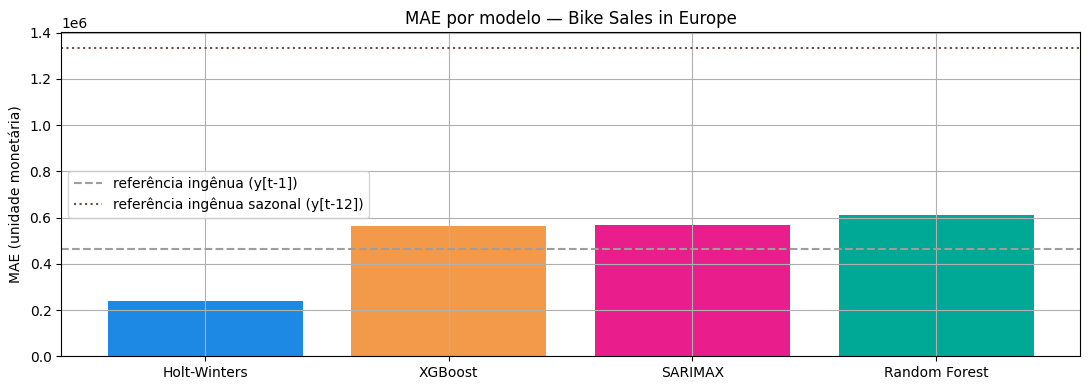

In [19]:
# 12. MAE por modelo, posição na base e arquivo para consolidação entre bases
mae_modelos = resultados.groupby("modelo")["erro_abs"].mean()
mae_ingenuo = mae_modelos["Ingênuo"]
mae_ingenuo_sazonal = mae_modelos["Ingênuo sazonal"]

tabela_mae = mae_modelos.loc[MODELOS].sort_values().to_frame("MAE")
tabela_mae["posicao"] = np.arange(1, len(tabela_mae) + 1)
tabela_mae["MAE / MAE ingênuo"] = tabela_mae["MAE"] / mae_ingenuo
tabela_mae["MAE / MAE ingênuo sazonal"] = tabela_mae["MAE"] / mae_ingenuo_sazonal
print(f"MAE da referência ingênua (y[t-1]): {mae_ingenuo:,.0f}")
print(f"MAE da referência ingênua sazonal (y[t-{M_SAZONAL}]): {mae_ingenuo_sazonal:,.0f}\n")
display(tabela_mae.style.format({"MAE": "{:,.0f}", "MAE / MAE ingênuo": "{:.2f}", "MAE / MAE ingênuo sazonal": "{:.2f}"}))

melhor_modelo = tabela_mae.index[0]
print(f"Melhor modelo nesta base: {melhor_modelo}")

# arquivo no formato da consolidação das 5 bases (vitórias e posição média são calculadas ENTRE bases)
(tabela_mae.reset_index().rename(columns={"index": "modelo"})
           .assign(base=BASE_NOME, grupo=GRUPO)[["grupo", "base", "modelo", "MAE", "posicao"]]
           .to_csv("mae_bike_sales.csv", index=False))

# complementar: vitórias por origem dentro desta base (não substitui a contagem entre bases)
r4 = resultados[resultados["modelo"].isin(MODELOS)].copy()
r4["rank_origem"] = r4.groupby("data")["erro_abs"].rank(method="min")
print("\nComplementar — vitórias por origem de previsão nesta base:")
print(r4[r4["rank_origem"] == 1]["modelo"].value_counts().reindex(MODELOS, fill_value=0))

fig, ax = plt.subplots()
ax.bar(tabela_mae.index, tabela_mae["MAE"], color=[PALETTE[m] for m in tabela_mae.index])
ax.axhline(mae_ingenuo, color=PALETTE["Ingênuo"], linestyle="--", label="referência ingênua (y[t-1])")
ax.axhline(mae_ingenuo_sazonal, color=PALETTE["Ingênuo sazonal"], linestyle=":", label=f"referência ingênua sazonal (y[t-{M_SAZONAL}])")
ax.set_title(f"MAE por modelo — {BASE_NOME}"); ax.set_ylabel("MAE (unidade monetária)"); ax.legend()
plt.tight_layout(); plt.show()

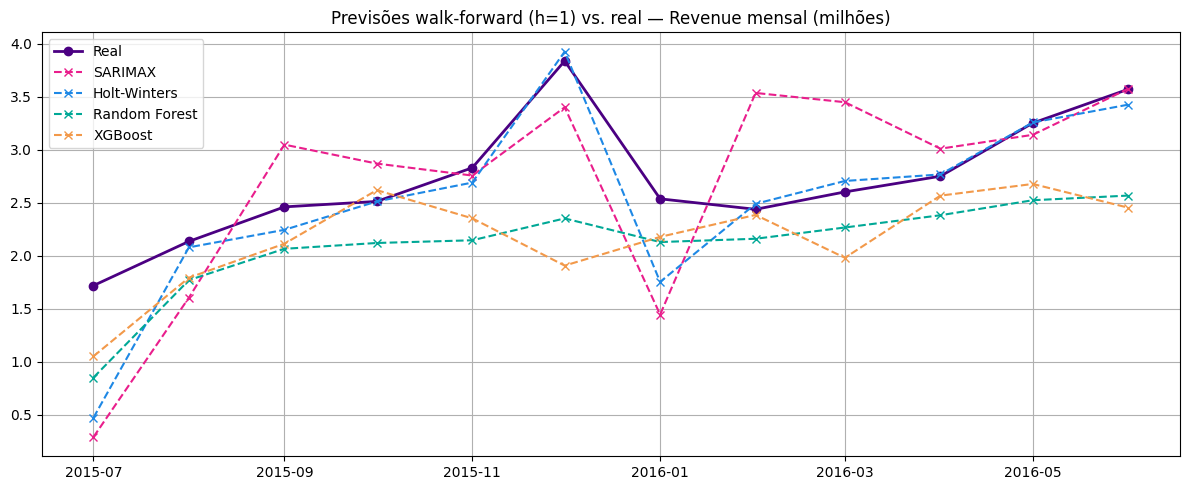

In [20]:
# 12.1 Previsões vs. real no bloco de teste
fig, ax = plt.subplots(figsize=(12, 5))
real = resultados[resultados["modelo"] == "Ingênuo"].set_index("data")["y_real"]
ax.plot(real.index, real / ESCALA, label="Real", color=PALETTE["real"], linewidth=2, marker="o")
for m in MODELOS:
    sub = resultados[resultados["modelo"] == m].set_index("data")
    ax.plot(sub.index, sub["y_previsto"] / ESCALA, label=m, color=PALETTE[m], linestyle="--", marker="x")
ax.set_title("Previsões walk-forward (h=1) vs. real — Revenue mensal (milhões)")
ax.legend(); plt.tight_layout(); plt.show()

**Discussão:**
- **Holt-Winters foi o único que bateu as referências ingênuas relevantes.** MAE 237.760 = 0,51 × o ingênuo
  (`y[t-1]`) e 0,18 × o ingênuo sazonal (`y[t-12]`). XGBoost (564.866), SARIMAX (568.564) e Random Forest
  (609.078) ficaram em 1,21–1,31 × o ingênuo, isto é, **pior que repetir o mês anterior**.
- **O ingênuo sazonal é o pior de todos** (MAE 1.334.140, 2,9 × o ingênuo simples). Repetir o mesmo mês do ano
  anterior erra feio porque a série não tem um padrão anual estável: o nível muda com o mix de produtos
  (salto em jul/2013, queda em jan/2015, nova subida em jul/2015). Em jan–jun/2016 o mês de referência
  (jan–jun/2015) está no patamar baixo e o real está em 2,4–3,6 milhões, o que gera erros de 1,8 a 2,8 milhões.
  Ressalva: nas origens de jul–dez/2015 o mês de referência é um valor imputado (jul–dez/2014).
  Todos os modelos ficam abaixo dele (razões entre 0,18 e 0,46), então a sazonalidade sozinha não explica
  a série, mas a sazonalidade **reajustada a cada origem** (Holt-Winters) ajuda.
- **Características da base:** série curta (66 meses), sazonalidade moderada (F<sub>s</sub> = 0,33) e mudanças
  de nível causadas pelo mix, não por calendário. Isso favorece quem acompanha o nível recente.
- **Extrapolação das árvores:** Random Forest e XGBoost subestimam a receita no teste (100% e 92% de resíduos
  positivos), coerente com a dificuldade das árvores em prever níveis acima do máximo visto no treino. É uma
  hipótese consistente com os resíduos, não foi testada à parte.
- **SARIMAX:** liderou a validação (175.159) e piorou no teste (568.564). Escolher a melhor de 2.270
  configurações com 12 pontos de validação favorece o sobreajuste à validação.


## 7. Análise dos resíduos

Resíduos fora da amostra (`y_real − y_previsto`) do bloco de teste. Com 12 pontos por modelo, o
Ljung-Box é aplicado nos lags 3 e 6 (no máximo n/2) e tem baixo poder: um p-valor alto indica
ausência de evidência de autocorrelação, não prova de independência.

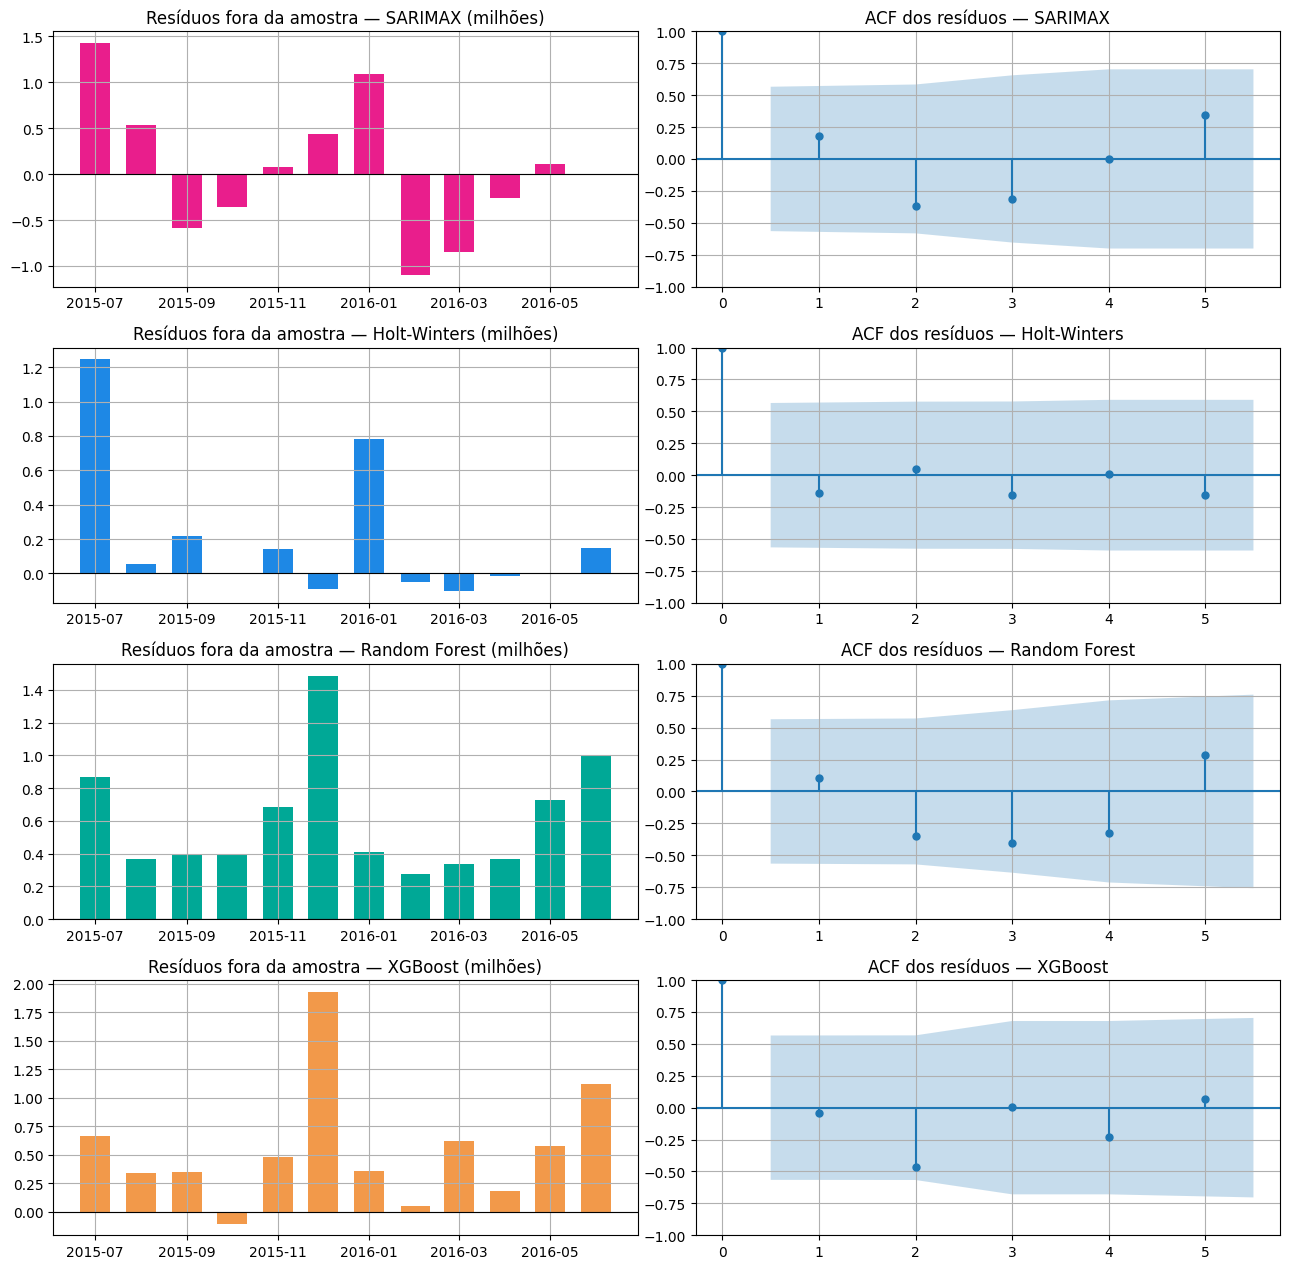

,viés médio,desvio-padrão,% resíduos > 0,LB stat (lag 3),p-valor (lag 3),LB stat (lag 6),p-valor (lag 6),autocorrelação (5%)
modelo,,,,,,,,
SARIMAX,"43,297","748,239",50%,4.68,0.197,9.26,0.159,sem indício
Holt-Winters,"193,462","407,833",58%,0.76,0.858,5.60,0.469,sem indício
Random Forest,"609,078","362,356",100%,5.24,0.155,12.64,0.049,há indício
XGBoost,"547,124","538,038",92%,3.70,0.295,8.17,0.226,sem indício


In [21]:
# 13. Resíduos fora da amostra: série no tempo, ACF, Ljung-Box, viés
linhas_lb = []
fig, axes = plt.subplots(len(MODELOS), 2, figsize=(13, 3.2 * len(MODELOS)))
for i, m in enumerate(MODELOS):
    res = resultados[resultados["modelo"] == m].set_index("data")["residuo"] / ESCALA
    axes[i, 0].bar(res.index, res.values, width=20, color=PALETTE[m])
    axes[i, 0].axhline(0, color="black", linewidth=0.8)
    axes[i, 0].set_title(f"Resíduos fora da amostra — {m} (milhões)")
    plot_acf(res.values, ax=axes[i, 1], lags=5)
    axes[i, 1].set_title(f"ACF dos resíduos — {m}")

    lb = acorr_ljungbox(res.values, lags=[3, 6], return_df=True)
    linhas_lb.append({"modelo": m,
                      "viés médio": res.mean() * ESCALA,
                      "desvio-padrão": res.std() * ESCALA,
                      "% resíduos > 0": (res > 0).mean(),
                      "LB stat (lag 3)": lb["lb_stat"].iloc[0], "p-valor (lag 3)": lb["lb_pvalue"].iloc[0],
                      "LB stat (lag 6)": lb["lb_stat"].iloc[1], "p-valor (lag 6)": lb["lb_pvalue"].iloc[1]})
plt.tight_layout(); plt.show()

tabela_ljung_box = pd.DataFrame(linhas_lb).set_index("modelo")
tabela_ljung_box["autocorrelação (5%)"] = np.where(
    tabela_ljung_box[["p-valor (lag 3)", "p-valor (lag 6)"]].min(axis=1) < 0.05, "há indício", "sem indício")
tabela_ljung_box.to_csv("bike_sales_ljung_box.csv")
display(tabela_ljung_box.style.format({"viés médio": "{:,.0f}", "desvio-padrão": "{:,.0f}", "% resíduos > 0": "{:.0%}",
                                       "LB stat (lag 3)": "{:.2f}", "p-valor (lag 3)": "{:.3f}",
                                       "LB stat (lag 6)": "{:.2f}", "p-valor (lag 6)": "{:.3f}"}))

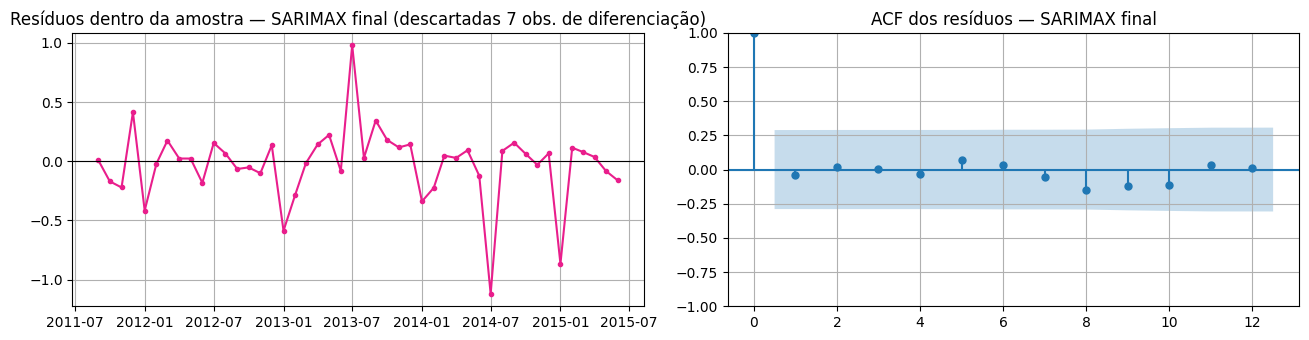

Ljung-Box (dentro da amostra):


,lb_stat,lb_pvalue
6,0.461,0.998
12,3.692,0.988


In [22]:
# 13.1 Diagnóstico dentro da amostra do SARIMAX final (ajustado em treino + validação)
cols_exog_final = EXOG_SETS[MELHOR_SARIMAX["exog"]]
t_corte = ORIGENS_TESTE[0]
amostra = slice(INICIO_SARIMAX, t_corte)
padronizador_final = StandardScaler().fit(base[cols_exog_final].iloc[amostra])
X_final = pd.DataFrame(padronizador_final.transform(base[cols_exog_final].iloc[amostra]),
                       columns=cols_exog_final, index=idx[amostra])
y_final = pd.Series(Y[amostra], index=idx[amostra]).asfreq("MS")
if MELHOR_SARIMAX["transf"] == "log":
    y_final = np.log(y_final)
sarimax_final = ajustar_sarimax(y_final, MELHOR_SARIMAX["order"], MELHOR_SARIMAX["seasonal_order"], X_final)

burn = MELHOR_SARIMAX["order"][1] + MELHOR_SARIMAX["seasonal_order"][1] * MELHOR_SARIMAX["seasonal_order"][3]
resid_in = sarimax_final.resid.iloc[burn:]
lb_in = acorr_ljungbox(resid_in, lags=[6, 12], return_df=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(resid_in.index, resid_in.values, color=PALETTE["SARIMAX"], marker="o", ms=3)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Resíduos dentro da amostra — SARIMAX final (descartadas {burn} obs. de diferenciação)")
plot_acf(resid_in, ax=axes[1], lags=min(12, len(resid_in) // 2 - 1))
axes[1].set_title("ACF dos resíduos — SARIMAX final")
plt.tight_layout(); plt.show()
print("Ljung-Box (dentro da amostra):"); display(lb_in.round(3))

**Discussão:**
- **Viés (resíduo = real − previsto; positivo = subestimação).** Random Forest (+609.078; 100% positivos) e
  XGBoost (+547.124; 92%) subestimam sistematicamente. Holt-Winters tem viés pequeno (+193.462; 58%), puxado por
  jul/2015 e jan/2016. SARIMAX tem viés próximo de zero (+43.297; 50%), mas com erros grandes de sinais
  alternados (jul/2015 e jan/2016 positivos, fev e mar/2016 negativos).
- **Variabilidade.** O SARIMAX tem o maior desvio-padrão (748.239); Holt-Winters o menor (407.833);
  Random Forest 362.356 e XGBoost 538.038.
- **Meses de maior erro.** SARIMAX e Holt-Winters erram mais em jul/2015, quando a série sobe de nível;
  Random Forest e XGBoost em dez/2015 (pico de cerca de 1,5 milhão no Random Forest).
- **Ljung-Box (lags 3 e 6).** Sem indício de autocorrelação em SARIMAX, Holt-Winters e XGBoost. No Random Forest
  há indício no lag 6 (p = 0,049). Com 12 pontos o teste tem baixo poder: p-valor alto é ausência de
  evidência, não prova de independência.
- **SARIMAX dentro da amostra:** Ljung-Box com p = 0,998 (lag 6) e 0,988 (lag 12). O bom ajuste dentro da
  amostra contrasta com o erro fora dela, o que reforça o sobreajuste à validação.


## 8. Importância das features e interpretação

- **Random Forest:** importância nativa (redução de impureza) e *Permutation Importance*.
- **XGBoost:** *gain* e *Permutation Importance*.
- **SARIMAX:** coeficientes padronizados das exógenas, sinal e p-valor.

Os modelos de árvore são reajustados em treino + validação com os hiperparâmetros fixos e a
permutação é avaliada no bloco de teste, no mesmo espaço de alvo do modelo (`nivel` ou
`diferenca`). As externas aparecem destacadas em laranja.

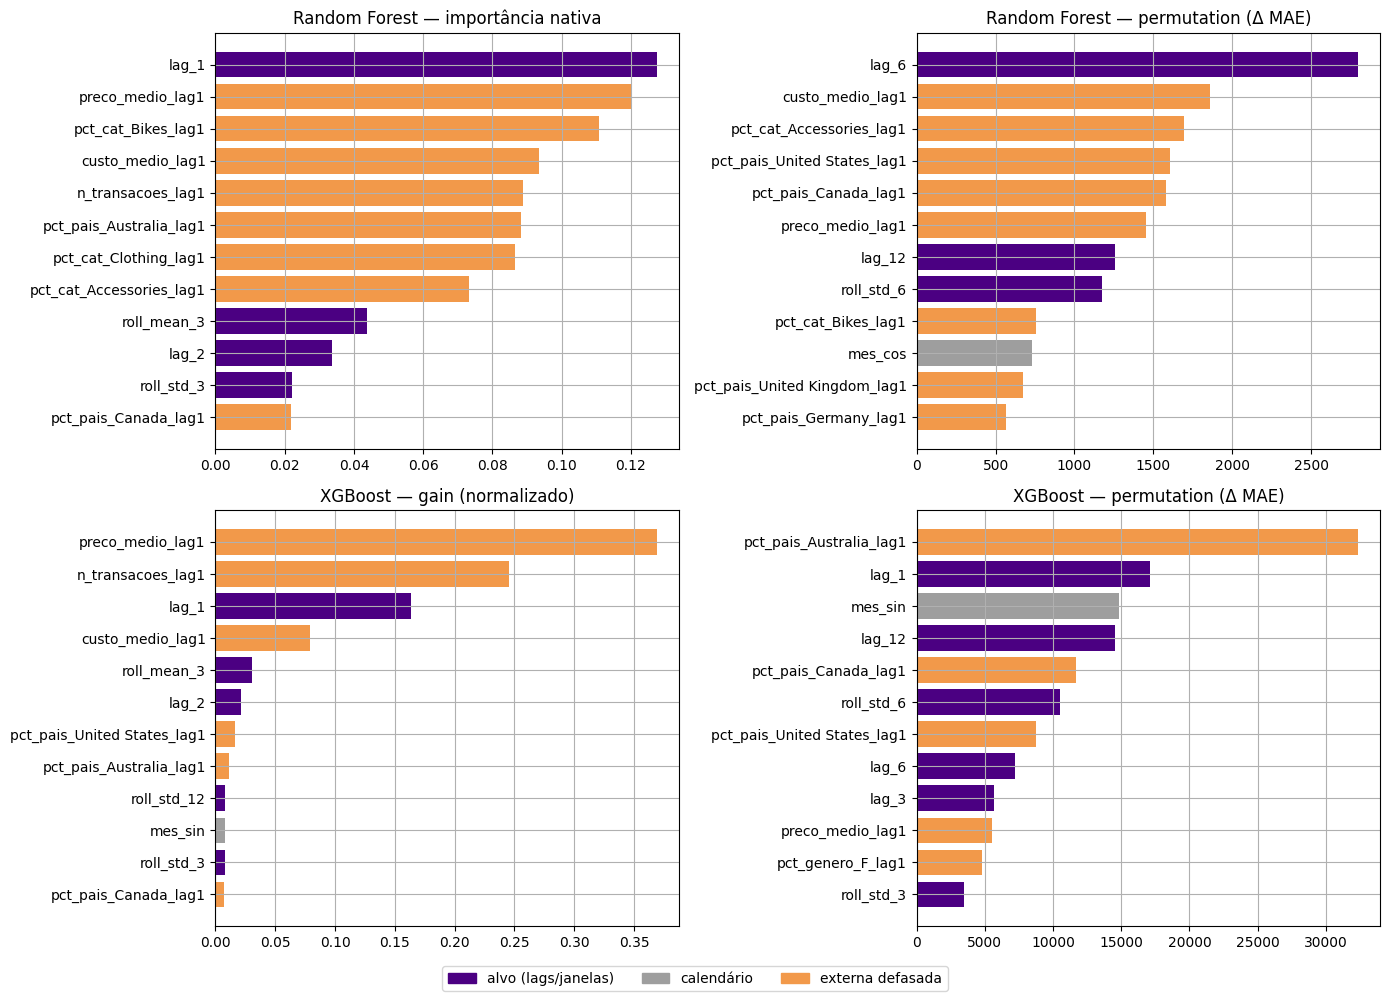

,RF nativa,XGB gain
participação das externas defasadas,0.699,0.744


In [23]:
# 14. Importância de features — RF e XGBoost
linhas_tv = np.arange(INICIO_FEATURES, ORIGENS_TESTE[0])
linhas_te = np.array(ORIGENS_TESTE)

def ajustar_final(fabrica, cfg):
    return fabrica(cfg["params"]).fit(XF[linhas_tv], alvo_modo(linhas_tv, cfg["modo"]))

def importancias(modelo, cfg):
    nativa = pd.Series(modelo.feature_importances_, index=FEATURE_COLS)
    perm = permutation_importance(modelo, XF[linhas_te], alvo_modo(linhas_te, cfg["modo"]),
                                  scoring="neg_mean_absolute_error", n_repeats=30, random_state=RNG)
    perm = pd.Series(perm.importances_mean * ESCALA, index=FEATURE_COLS)  # aumento de MAE (unid. monetária)
    return nativa.sort_values(ascending=False), perm.sort_values(ascending=False)

rf_final = ajustar_final(fabrica_rf, MELHOR_RF)
xgb_final = ajustar_final(fabrica_xgb, MELHOR_XGB)
xgb_final.get_booster().feature_names = FEATURE_COLS
imp_rf_nativa, imp_rf_perm = importancias(rf_final, MELHOR_RF)
imp_xgb_nativa, imp_xgb_perm = importancias(xgb_final, MELHOR_XGB)
gain = pd.Series(xgb_final.get_booster().get_score(importance_type="gain")).reindex(FEATURE_COLS).fillna(0)
imp_xgb_gain = (gain / gain.sum()).sort_values(ascending=False)

def cor(f):
    return "#F2994A" if f in FEATURES_EXTERNAS else ("#9E9E9E" if f in FEATURES_CALENDARIO else "#4B0082")

paineis = [(imp_rf_nativa, "Random Forest — importância nativa"),
           (imp_rf_perm, "Random Forest — permutation (Δ MAE)"),
           (imp_xgb_gain, "XGBoost — gain (normalizado)"),
           (imp_xgb_perm, "XGBoost — permutation (Δ MAE)")]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (s, titulo) in zip(axes.ravel(), paineis):
    top = s.head(12)[::-1]
    ax.barh(top.index, top.values, color=[cor(f) for f in top.index]); ax.set_title(titulo)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#4B0082", "#9E9E9E", "#F2994A"]],
           labels=["alvo (lags/janelas)", "calendário", "externa defasada"], loc="lower center", ncol=3)
plt.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

participacao_externas = pd.DataFrame({
    "RF nativa": imp_rf_nativa[FEATURES_EXTERNAS].sum() / imp_rf_nativa.sum(),
    "XGB gain": imp_xgb_gain[FEATURES_EXTERNAS].sum(),
}, index=["participação das externas defasadas"])
display(participacao_externas.round(3))

In [24]:
# 14.1 SARIMAX — coeficientes das exógenas (padronizadas) do modelo final
tabela_coef = pd.DataFrame({"coef": sarimax_final.params, "erro_padrao": sarimax_final.bse,
                            "z": sarimax_final.tvalues, "p_valor": sarimax_final.pvalues})
tabela_coef["tipo"] = np.where(tabela_coef.index.isin(cols_exog_final), "exógena", "estrutura ARIMA")
print(f"SARIMAX final: {MELHOR_SARIMAX} | alvo em {'log(milhões)' if MELHOR_SARIMAX['transf'] == 'log' else 'milhões'}")
display(tabela_coef.round(4))
print("Exógenas padronizadas: o coeficiente é o efeito de +1 desvio-padrão da exógena sobre o alvo transformado.")

SARIMAX final: {'transf': 'log', 'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 6), 'exog': 'idade_media_lag1+pct_cat_Accessories_lag1+pct_pais_Germany_lag1'} | alvo em log(milhões)


,coef,erro_padrao,z,p_valor,tipo
idade_media_lag1,0.0071,0.0744,0.0948,0.9244,exógena
pct_cat_Accessories_lag1,0.2627,0.2802,0.9375,0.3485,exógena
pct_pais_Germany_lag1,0.0890,0.0916,0.9708,0.3317,exógena
ma.L1,-0.4520,0.4315,-1.0475,0.2949,estrutura ARIMA
ma.L2,0.2112,0.2571,0.8216,0.4113,estrutura ARIMA
ar.S.L6,-0.5759,0.0885,-6.5101,0.0000,estrutura ARIMA
sigma2,0.0945,0.0216,4.3689,0.0000,estrutura ARIMA


Exógenas padronizadas: o coeficiente é o efeito de +1 desvio-padrão da exógena sobre o alvo transformado.


**Interpretação:**
- **Random Forest e XGBoost:** as externas defasadas somam 69,9% da importância nativa do Random Forest e 74,4%
  do gain do XGBoost. Na nativa, `lag_1`, `preco_medio_lag1`, `pct_cat_Bikes_lag1` e `custo_medio_lag1` lideram
  no Random Forest; no XGBoost, `preco_medio_lag1` (≈ 0,37), `n_transacoes_lag1` (≈ 0,25) e `lag_1` (≈ 0,16).
- **A permutação não confirma a nativa.** No Random Forest lideram `lag_6`, `custo_medio_lag1` e
  `pct_cat_Accessories_lag1`; no XGBoost, `pct_pais_Australia_lag1` com folga. A importância nativa favorece
  variáveis contínuas com muitos valores distintos (preço e custo médios). Os aumentos de MAE por permutação são
  pequenos frente ao MAE do modelo, então nenhuma feature isolada explica o desempenho.
- **SARIMAX:** nenhuma das três exógenas é significativa (p entre 0,33 e 0,92); só o termo AR sazonal
  (`ar.S.L6` = −0,576; p < 0,001) é significativo.
- **Papel das externas:** relevantes nas árvores, mas sem ganho final (o Holt-Winters, que não usa nenhuma,
  venceu). **Disponibilidade:** todas as externas usadas estão defasadas em 1 mês, logo são conhecidas na
  origem; o calendário é conhecido antecipadamente.


## Apoio à consolidação das 5 bases

Vitórias e posição média são calculadas **entre bases** a partir dos arquivos `mae_<base>.csv`
gerados por cada notebook.

In [25]:
# 15. Consolidação entre bases (executar quando os 5 arquivos de MAE existirem)
def consolidar_bases(caminhos_csv):
    todos = pd.concat([pd.read_csv(c) for c in caminhos_csv], ignore_index=True)
    todos["posicao"] = todos.groupby("base")["MAE"].rank(method="min")
    vitorias = todos[todos["posicao"] == 1]["modelo"].value_counts().reindex(MODELOS, fill_value=0)
    posicao_media = todos.groupby("modelo")["posicao"].mean().reindex(MODELOS)
    resumo = pd.DataFrame({"vitórias": vitorias, "posição média": posicao_media}).sort_values("posição média")
    tabela_larga = todos.pivot(index="base", columns="modelo", values="MAE")[MODELOS]
    return tabela_larga, resumo

# exemplo de uso:
# tabela_mae_bases, resumo_modelos = consolidar_bases(["mae_bike_sales.csv", "mae_base2.csv", ...])
tabela_mae_bases, resumo_modelos = consolidar_bases(["mae_bike_sales.csv"])
display(resumo_modelos)

,vitórias,posição média
modelo,,
Holt-Winters,1,1.0
XGBoost,0,2.0
SARIMAX,0,3.0
Random Forest,0,4.0
